# FFNN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from ffnn.model import FFNN

## Data Preprocessing

In [ ]:
df = pd.read_csv("src/data/datasetml_2026.csv")

print("Shape:")
print(df.shape)

print("\nTypes:")
print(df.dtypes)

print("\nHead:")
print(df.head())

Shape:
(10000, 12)

Types:
cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
                             ...   
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
Length: 12, dtype: object

Head:
       cgpa  backlogs college_tier country university_ranking_band  \
0  7.397371         1       Tier 2  Canada                 100-300   
1  6.889389         0       Tier 3      UK                    300+   
2  7.518151         0       Tier 1      UK                 100-300   
3  8.218424         0       Tier 2      UK                 100-300   
4  6.812677         1       Tier 2     USA                 100-300   

   internship_count  aptitude_score  communication_score specialization  \
0                 2       53.574150            6

In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["placement_status"].value_counts())

Missing values:
cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
                           ..
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
Length: 12, dtype: int64

Target distribution:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


In [ ]:
num_cols = [
    "cgpa",
    "backlogs",
    "internship_count",
    "aptitude_score",
    "communication_score",
    "internship_quality_score",
]
cat_cols = [
    "college_tier",
    "country",
    "university_ranking_band",
    "specialization",
    "industry",
]

In [ ]:
df_encoded = pd.get_dummies(
    df.copy(),
    columns=cat_cols,
    drop_first=True,
    dtype=float,
)

print(df_encoded.shape)
print(df_encoded.columns.tolist())

(10000, 24)
['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score', 'placement_status', 'college_tier_Tier 2', 'college_tier_Tier 3', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'university_ranking_band_300+', 'university_ranking_band_Top 100', 'specialization_Cloud', 'specialization_Core CS', 'specialization_Cybersecurity', 'specialization_Data Science', 'industry_Finance', 'industry_Healthcare', 'industry_Manufacturing', 'industry_Other', 'industry_Tech']


In [ ]:
le = LabelEncoder()
y = (
    le.fit_transform(df_encoded["placement_status"])
    .reshape(-1, 1)
    .astype(np.float64)
)

print("Target classes: ")
print(le.classes_)

print("\nTarget shape:")
print(y.shape)

print("\nSample values: ")
print(y[:5])

Target classes: 
['Not Placed' 'Placed']

Target shape:
(10000, 1)

Sample values: 
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [ ]:
feature_cols = [col for col in df_encoded.columns if col != "placement_status"]
X = df_encoded[feature_cols].values.astype(np.float64)

print(X.shape)
print(feature_cols)

(10000, 23)
['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score', 'college_tier_Tier 2', 'college_tier_Tier 3', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'university_ranking_band_300+', 'university_ranking_band_Top 100', 'specialization_Cloud', 'specialization_Core CS', 'specialization_Cybersecurity', 'specialization_Data Science', 'industry_Finance', 'industry_Healthcare', 'industry_Manufacturing', 'industry_Other', 'industry_Tech']


In [ ]:
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"  X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}  y_val   : {y_val.shape}")
print(f"  X_val  : {X_val.shape}  y_val  : {y_val.shape}")

  X_train : (6400, 23)  y_train : (6400, 1)
  X_val   : (1600, 23)  y_val   : (1600, 1)
  X_val  : (1600, 23)  y_val  : (1600, 1)


In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train.ravel())
y_train_sm = y_train_sm.reshape(-1, 1)

print(f"  Before SMOTE : {X_train.shape}  {y_train.shape}")
print(f"  After  SMOTE : {X_train_sm.shape}  {y_train_sm.shape}")

  Before SMOTE : (6400, 23)  (6400, 1)
  After  SMOTE : (7892, 23)  (7892, 1)


In [ ]:
idx_num = [i for i, col in enumerate(feature_cols) if col in num_cols]

scaler = StandardScaler()

X_train_final = X_train_sm.copy()
X_val_final = X_val.copy()
X_val_final = X_val.copy()

X_train_final[:, idx_num] = scaler.fit_transform(X_train_sm[:, idx_num])
X_val_final[:, idx_num] = scaler.transform(X_val[:, idx_num])
X_val_final[:, idx_num] = scaler.transform(X_val[:, idx_num])

X_train_final = X_train_final.astype(np.float64)
X_val_final = X_val_final.astype(np.float64)
X_val_final = X_val_final.astype(np.float64)

y_train_final = y_train_sm.astype(np.float64)
y_val_final = y_val.astype(np.float64)
y_val_final = y_val.astype(np.float64)

print(f"  X_train : {X_train_final.shape}  y_train : {y_train_final.shape}")
print(f"  X_val   : {X_val_final.shape}  y_val   : {y_val_final.shape}")
print(f"  X_val  : {X_val_final.shape}  y_val  : {y_val_final.shape}")

  X_train : (7892, 23)  y_train : (7892, 1)
  X_val   : (1600, 23)  y_val   : (1600, 1)
  X_val  : (1600, 23)  y_val  : (1600, 1)


## Experiments

In [ ]:
import marimo as mo

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

def build_and_train(
    hidden_sizes,
    activations_hidden,
    *,
    lr=0.01,
    epochs=100,
    batch_size=32,
    initializer="uniform",
    regularizer="none",
    reg_kwargs=None,
):
    n_in = X_train_final.shape[1]
    layer_sizes = [n_in] + list(hidden_sizes) + [1]
    activations = list(activations_hidden) + ["sigmoid"]

    model = FFNN(
        layer_sizes=layer_sizes,
        activations=activations,
        loss="bce",
        initializer=initializer,
        regularizer=regularizer,
        reg_kwargs=reg_kwargs or {},
    )
    history = model.fit(
        X_train_final,
        y_train_final,
        batch_size=batch_size,
        learning_rate=lr,
        epochs=epochs,
        verbose=0,
        validation_data=(X_val_final, y_val_final),
    )
    return model, history

def eval_model(model, X, y_true):
    y_pred = model.predict(X)
    y_flat = y_true.flatten().astype(int)
    kw = dict(average="weighted", zero_division=0)
    return {
        "Accuracy": round(accuracy_score(y_flat, y_pred), 4),
        "F1": round(f1_score(y_flat, y_pred, **kw), 4),
        "Precision": round(precision_score(y_flat, y_pred, **kw), 4),
        "Recall": round(recall_score(y_flat, y_pred, **kw), 4),
    }

def refresh_gradients(model, X, y):
    y_pred = model.forward(X)
    model.backward(y, y_pred)

def plot_loss_curves(histories, labels, title="Loss Curves"):
    colors = plt.cm.tab10.colors
    fig, (ax_tr, ax_val) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        ax_tr.plot(hist["train_loss"], label=lbl, color=c)
        if hist["val_loss"]:
            ax_val.plot(hist["val_loss"], label=lbl, color=c)

    for ax, name in zip((ax_tr, ax_val), ("Train Loss", "Val Loss")):
        ax.set_title(name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_wgrad_dists(
    models, labels, layer_idx, title="Weight & Gradient Distributions"
):
    import numpy as _np

    n = len(models)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    if n == 1:
        axes = axes.reshape(2, 1)

    for j, (model, lbl) in enumerate(zip(models, labels)):
        W = model.layers[layer_idx].W.flatten()
        dW = model.layers[layer_idx].dW.flatten()

        axes[0, j].hist(W, bins=60, color="steelblue", alpha=0.8, edgecolor="none")
        axes[0, j].set_title(f"Weights\n{lbl}", fontsize=9)
        axes[0, j].set_xlabel("Value")
        axes[0, j].set_ylabel("Count")

        axes[1, j].hist(dW, bins=60, color="tomato", alpha=0.8, edgecolor="none")
        axes[1, j].set_title(f"Gradients\n{lbl}", fontsize=9)
        axes[1, j].set_xlabel("Value")
        axes[1, j].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

### Exp 1a – Width Variation (depth fixed at 2 hidden layers)

| Config | Hidden layers |
|--------|--------------|
| A | [16, 16] |
| B | [64, 64] |
| C | [256, 256] |

Fixed: `lr=0.01`, `epochs=100`, `batch_size=32`, `activation=relu`, `init=uniform`

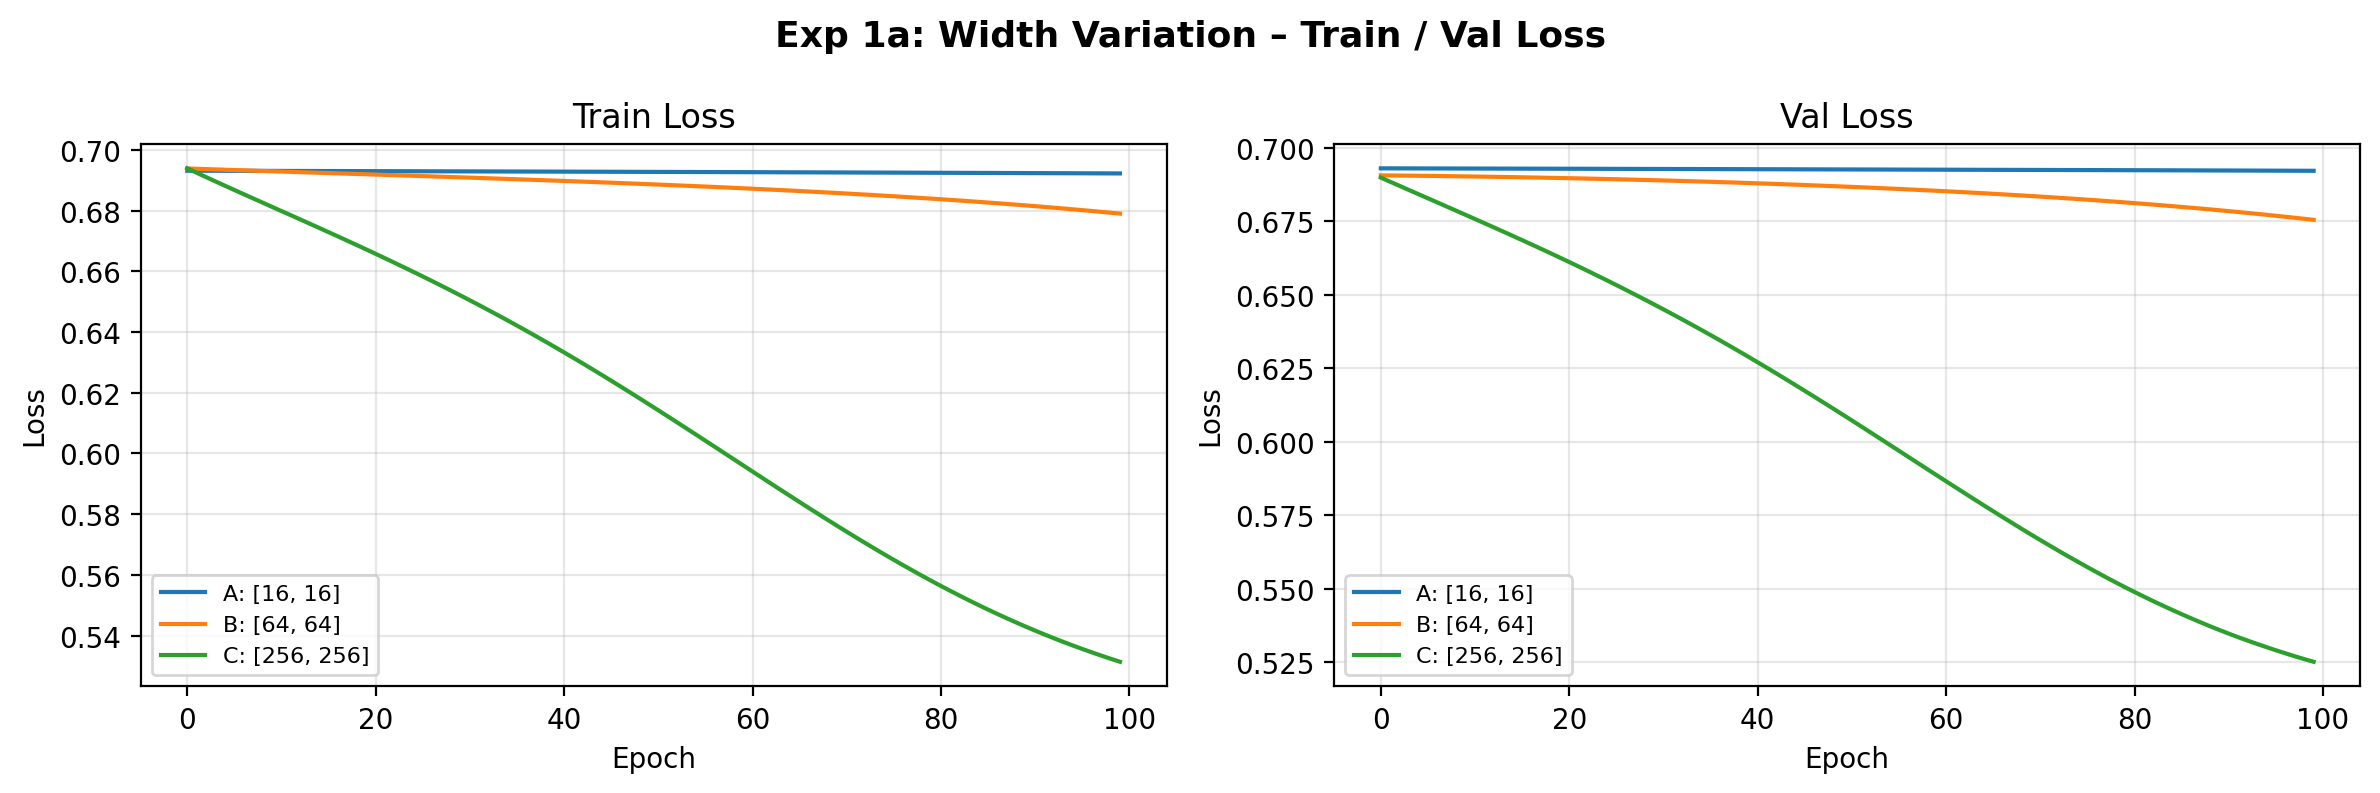


Exp 1a – Final Metrics
               Accuracy      F1  Precision  Recall
Config                                            
A: [16, 16]      0.6637  0.6669     0.6735  0.6637
B: [64, 64]      0.7394  0.7376     0.7368  0.7394
C: [256, 256]    0.7444  0.7464     0.7509  0.7444


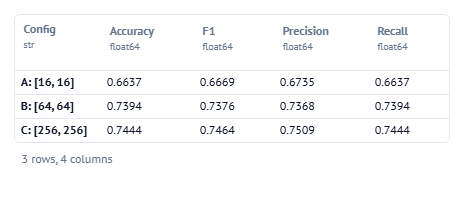

In [ ]:
_configs_1a = {
    "A: [16, 16]": [16, 16],
    "B: [64, 64]": [64, 64],
    "C: [256, 256]": [256, 256],
}

_histories_1a, _rows_1a = [], []

for _lbl, _hidden in _configs_1a.items():
    _model, _hist = build_and_train(
        _hidden,
        ["relu"] * len(_hidden),
        lr=0.01,
        epochs=100,
        batch_size=32,
    )
    _metrics = eval_model(_model, X_val_final, y_val_final)
    _histories_1a.append(_hist)
    _rows_1a.append({"Config": _lbl, **_metrics})

plot_loss_curves(
    _histories_1a,
    list(_configs_1a.keys()),
    "Exp 1a: Width Variation – Train / Val Loss",
)

_df_1a = pd.DataFrame(_rows_1a).set_index("Config")
print("\nExp 1a – Final Metrics")
print(_df_1a.to_string())
_df_1a

### Exp 1b – Depth Variation (width fixed at 64 per layer)

| Config | Hidden layers |
|--------|--------------|
| A | [64] |
| B | [64, 64, 64] |
| C | [64, 64, 64, 64, 64] |

Fixed: `lr=0.01`, `epochs=100`, `batch_size=32`, `activation=relu`, `init=uniform`

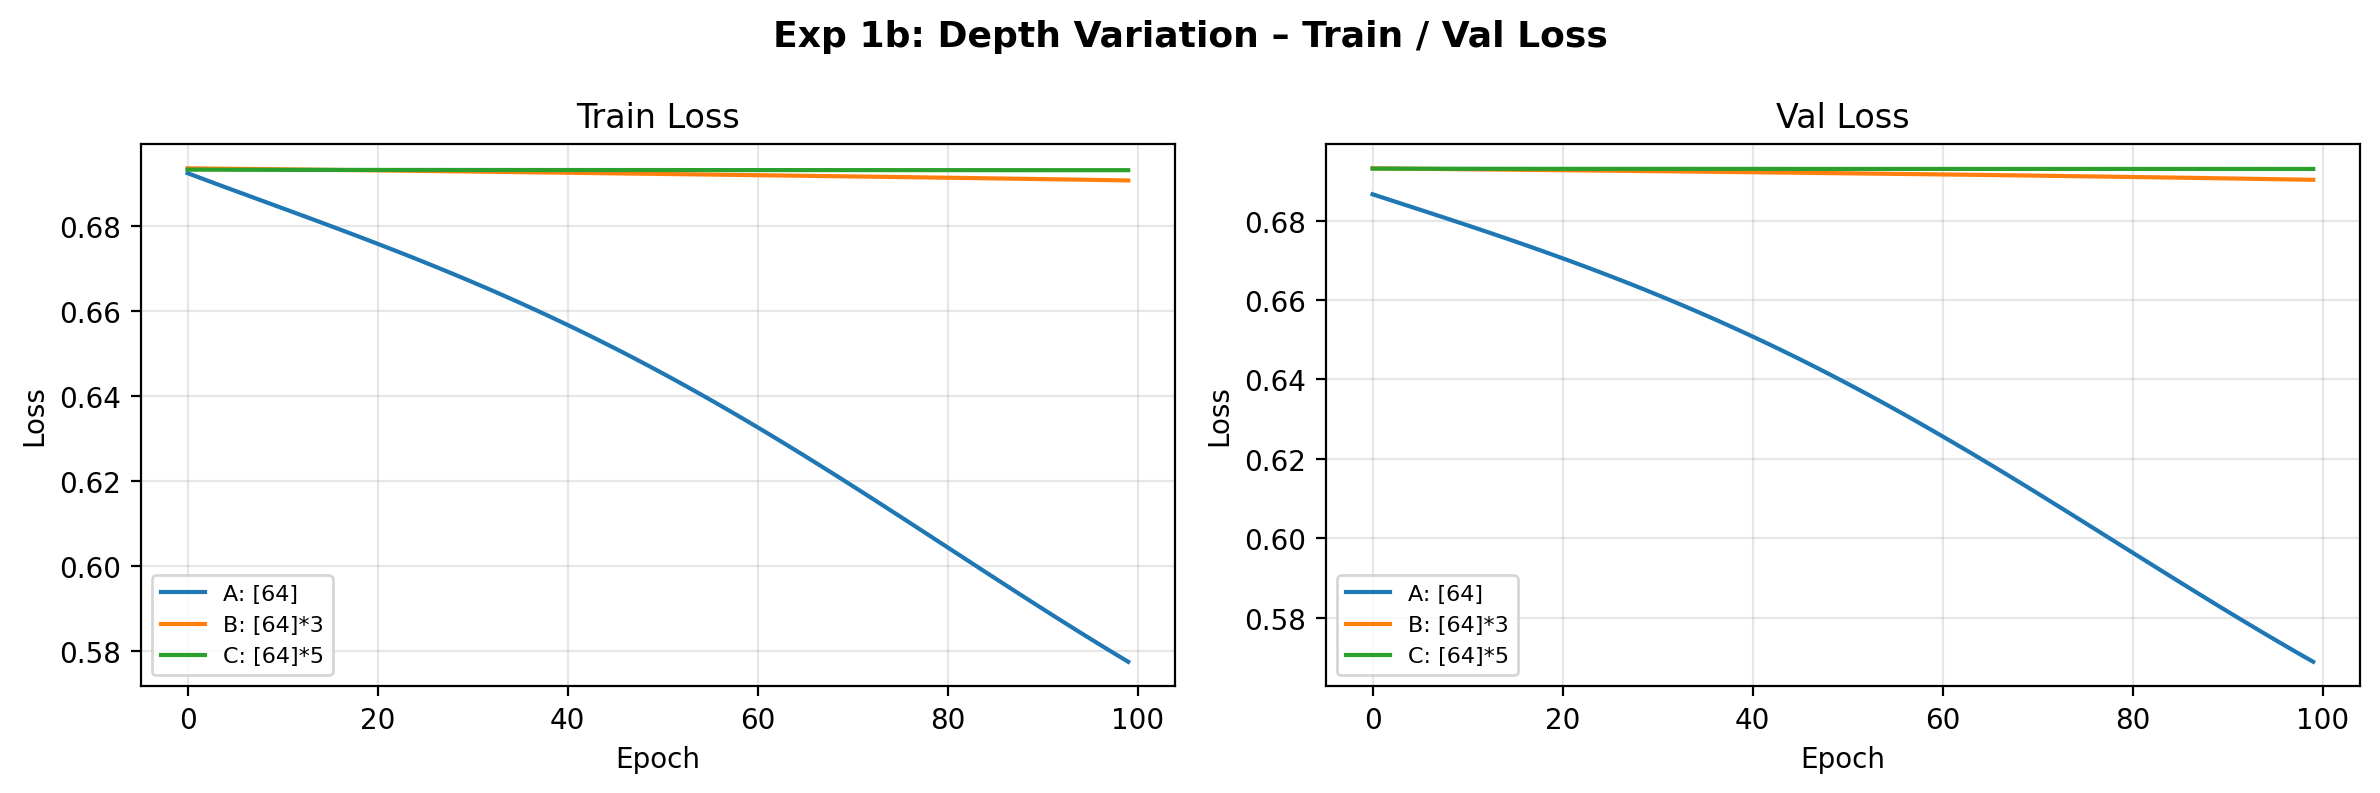


Exp 1b – Final Metrics
           Accuracy      F1  Precision  Recall
Config                                        
A: [64]      0.7425  0.7451     0.7529  0.7425
B: [64]*3    0.7075  0.7085     0.7098  0.7075
C: [64]*5    0.6813  0.6826     0.6846  0.6813


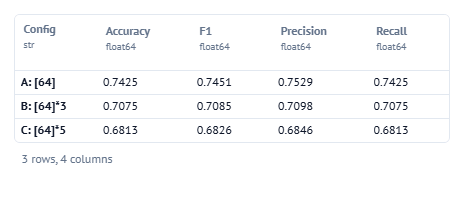

In [ ]:
_configs_1b = {
    "A: [64]": [64],
    "B: [64]*3": [64, 64, 64],
    "C: [64]*5": [64, 64, 64, 64, 64],
}

_histories_1b, _rows_1b = [], []

for _lbl, _hidden in _configs_1b.items():
    _model, _hist = build_and_train(
        _hidden,
        ["relu"] * len(_hidden),
        lr=0.01,
        epochs=100,
        batch_size=32,
    )
    _metrics = eval_model(_model, X_val_final, y_val_final)
    _histories_1b.append(_hist)
    _rows_1b.append({"Config": _lbl, **_metrics})

plot_loss_curves(
    _histories_1b,
    list(_configs_1b.keys()),
    "Exp 1b: Depth Variation – Train / Val Loss",
)

_df_1b = pd.DataFrame(_rows_1b).set_index("Config")
print("\nExp 1b – Final Metrics")
print(_df_1b.to_string())
_df_1b

### Exp 2 – Activation Function Variation

Architecture: `input → 64 (relu) → 64 (TEST) → 64 (relu) → output (sigmoid)`

The **test layer** (`model.layers[1]`, the middle hidden layer) cycles through:
`linear`, `relu`, `sigmoid`, `tanh`. All other layers are fixed to ReLU.

Plots:
- Train / Val loss curves for all 4 models
- Weight distribution of the test layer after training
- Gradient distribution of the test layer after training

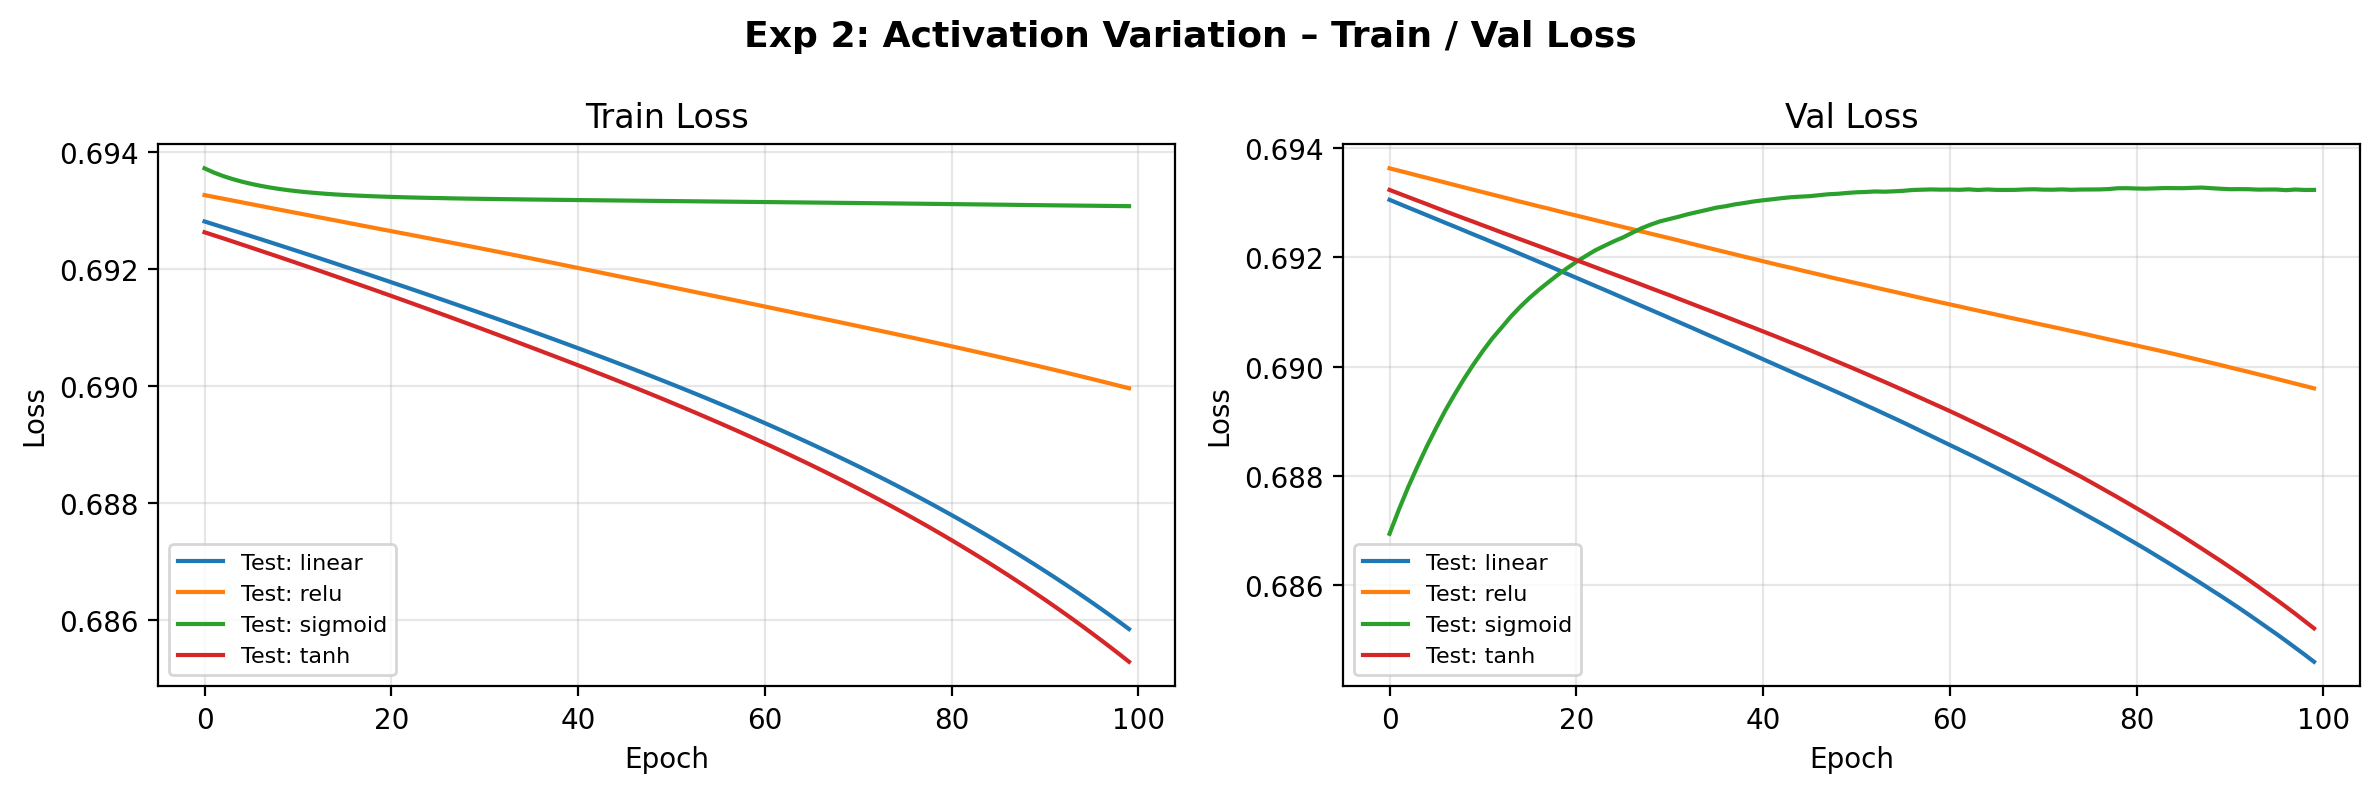

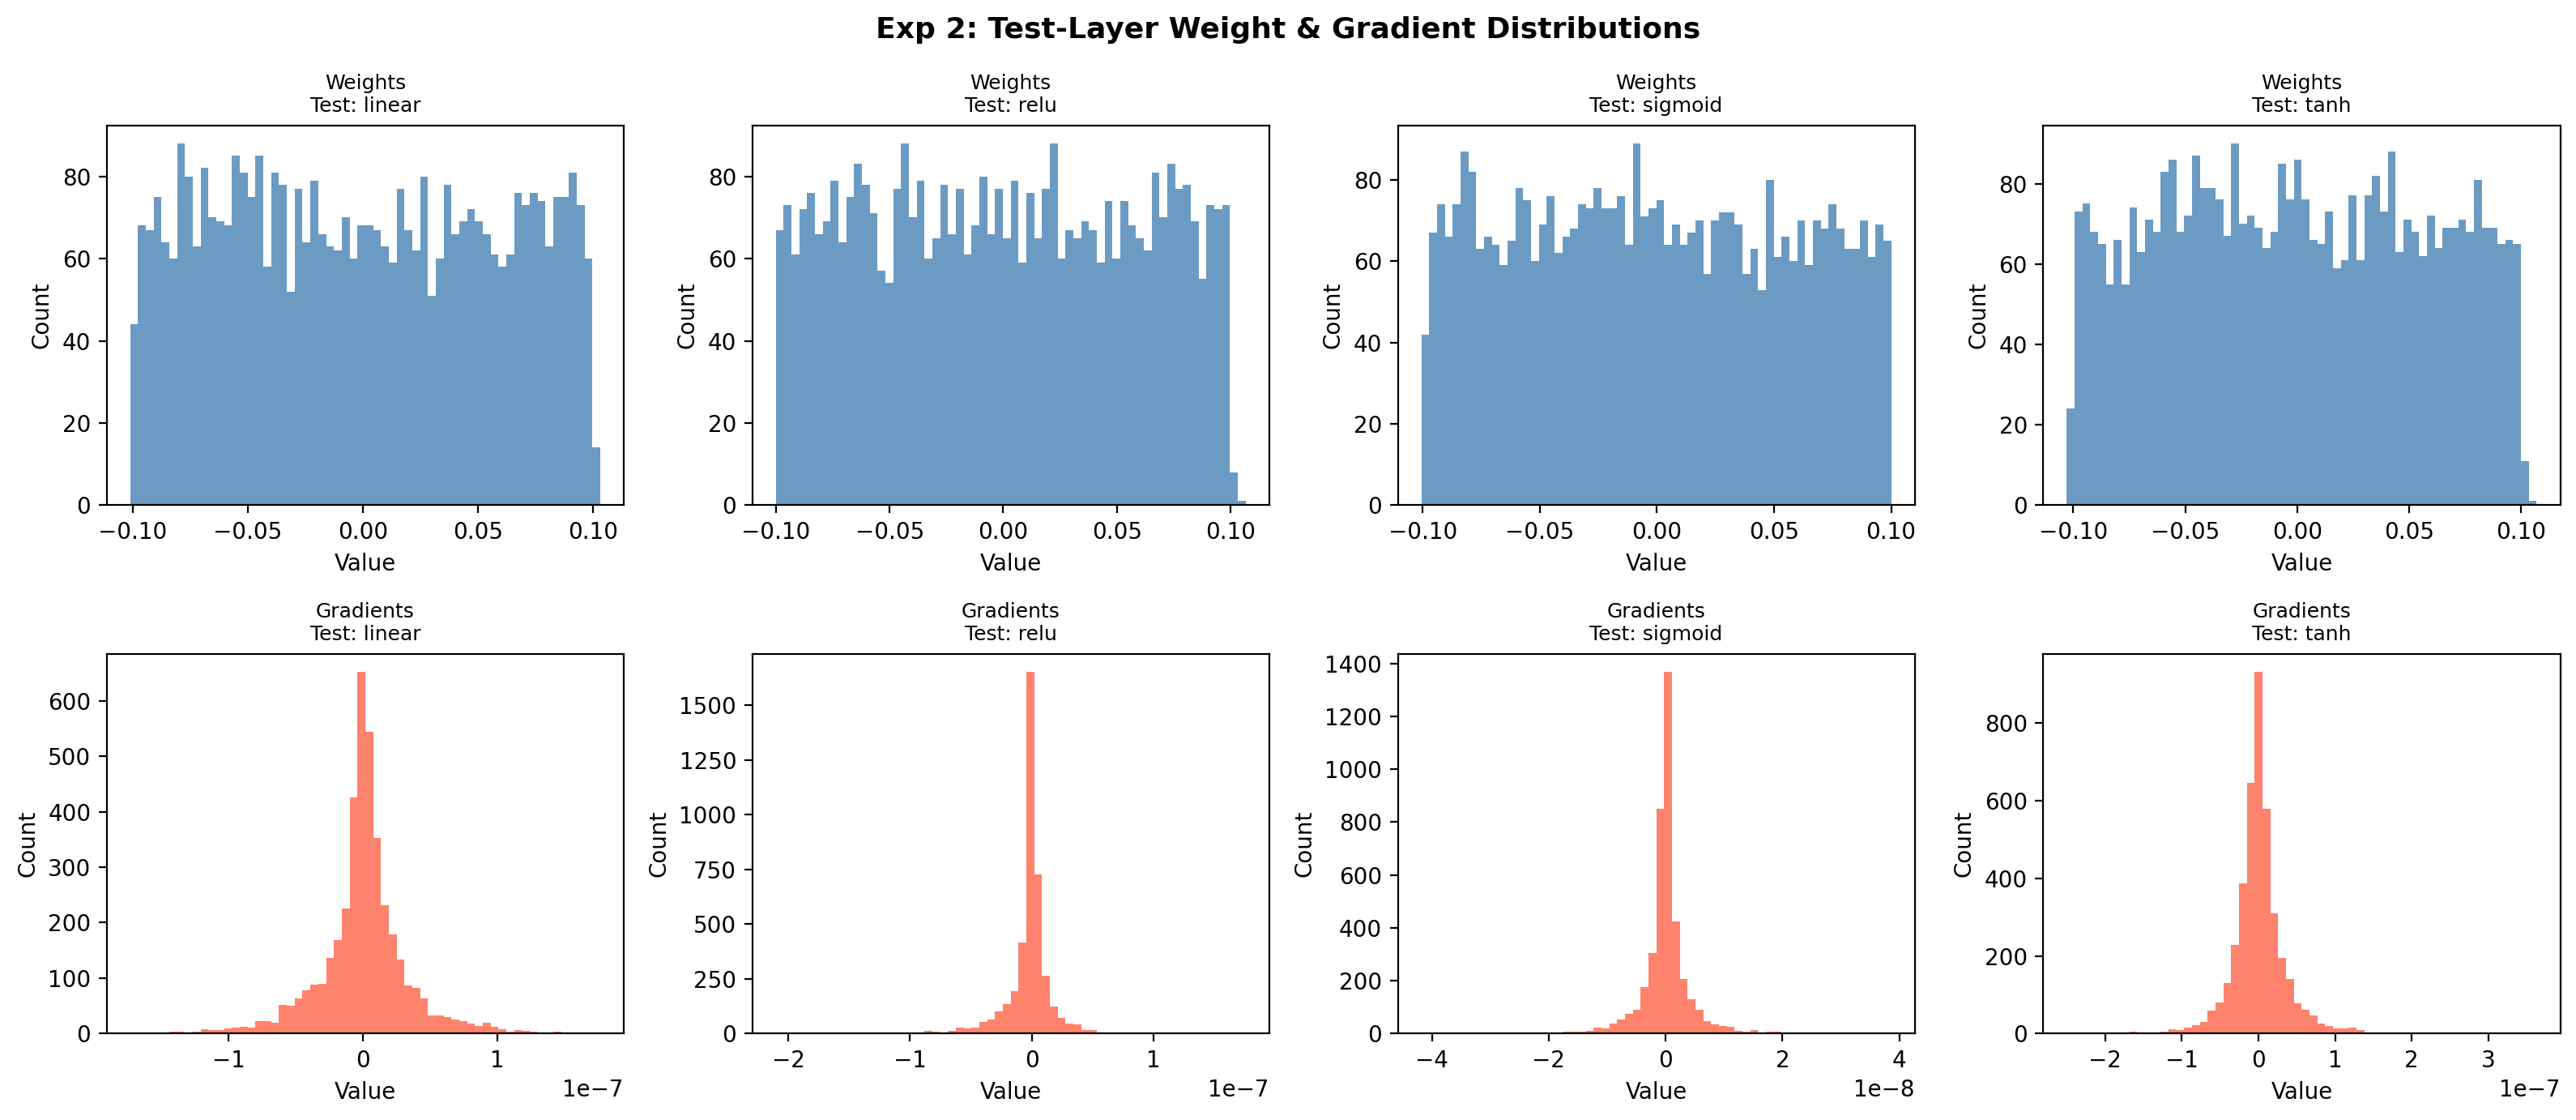


Exp 2 – Final Metrics
            Accuracy      F1  Precision  Recall
Activation                                     
linear        0.7244  0.7243     0.7243  0.7244
relu          0.7350  0.7339     0.7332  0.7350
sigmoid       0.4356  0.3496     0.6016  0.4356
tanh          0.7212  0.7249     0.7463  0.7212


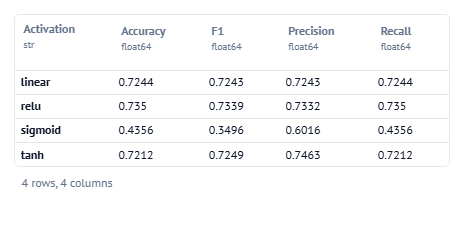

In [ ]:
_TEST_LAYER_IDX = 1
_test_acts = ["linear", "relu", "sigmoid", "tanh"]

_histories_2, _models_2, _labels_2, _rows_2 = [], [], [], []

for _act in _test_acts:
    _model, _hist = build_and_train(
        [64, 64, 64],
        ["relu", _act, "relu"],
        lr=0.01,
        epochs=100,
        batch_size=32,
    )
    refresh_gradients(_model, X_train_final, y_train_final)
    _metrics = eval_model(_model, X_val_final, y_val_final)
    _histories_2.append(_hist)
    _models_2.append(_model)
    _labels_2.append(f"Test: {_act}")
    _rows_2.append({"Activation": _act, **_metrics})

plot_loss_curves(
    _histories_2,
    _labels_2,
    "Exp 2: Activation Variation – Train / Val Loss",
)
plot_wgrad_dists(
    _models_2,
    _labels_2,
    _TEST_LAYER_IDX,
    "Exp 2: Test-Layer Weight & Gradient Distributions",
)

_df_2 = pd.DataFrame(_rows_2).set_index("Activation")
print("\nExp 2 – Final Metrics")
print(_df_2.to_string())
_df_2

### Exp 3 – Learning Rate Variation

Architecture: `input → 64 (relu) → 64 (relu) → output (sigmoid)`

| Run | LR |
|-----|----|
| A | 0.001 |
| B | 0.01 |
| C | 0.1 |

> **Note:** LR C (0.1) may cause the loss to diverge or oscillate significantly.
> This is expected behaviour and is visible in the curves below.

Plots: loss curves + weight & gradient distributions for `model.layers[1]`.

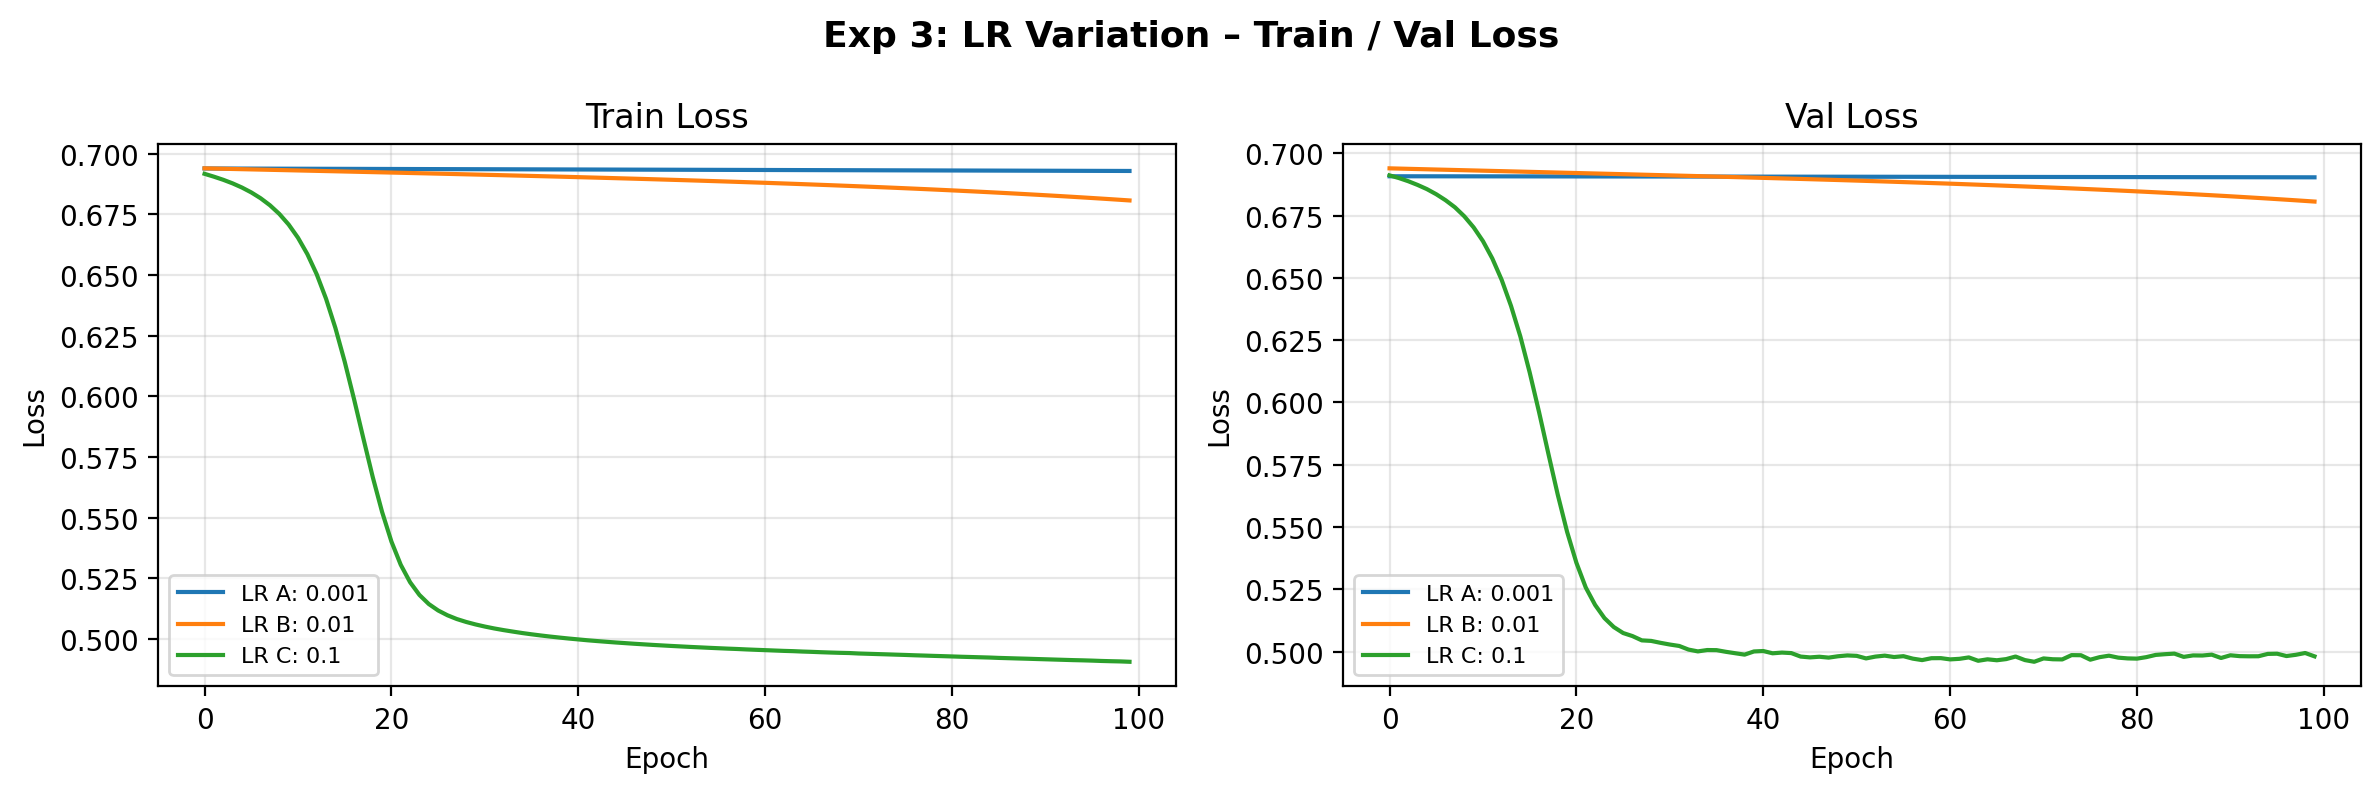

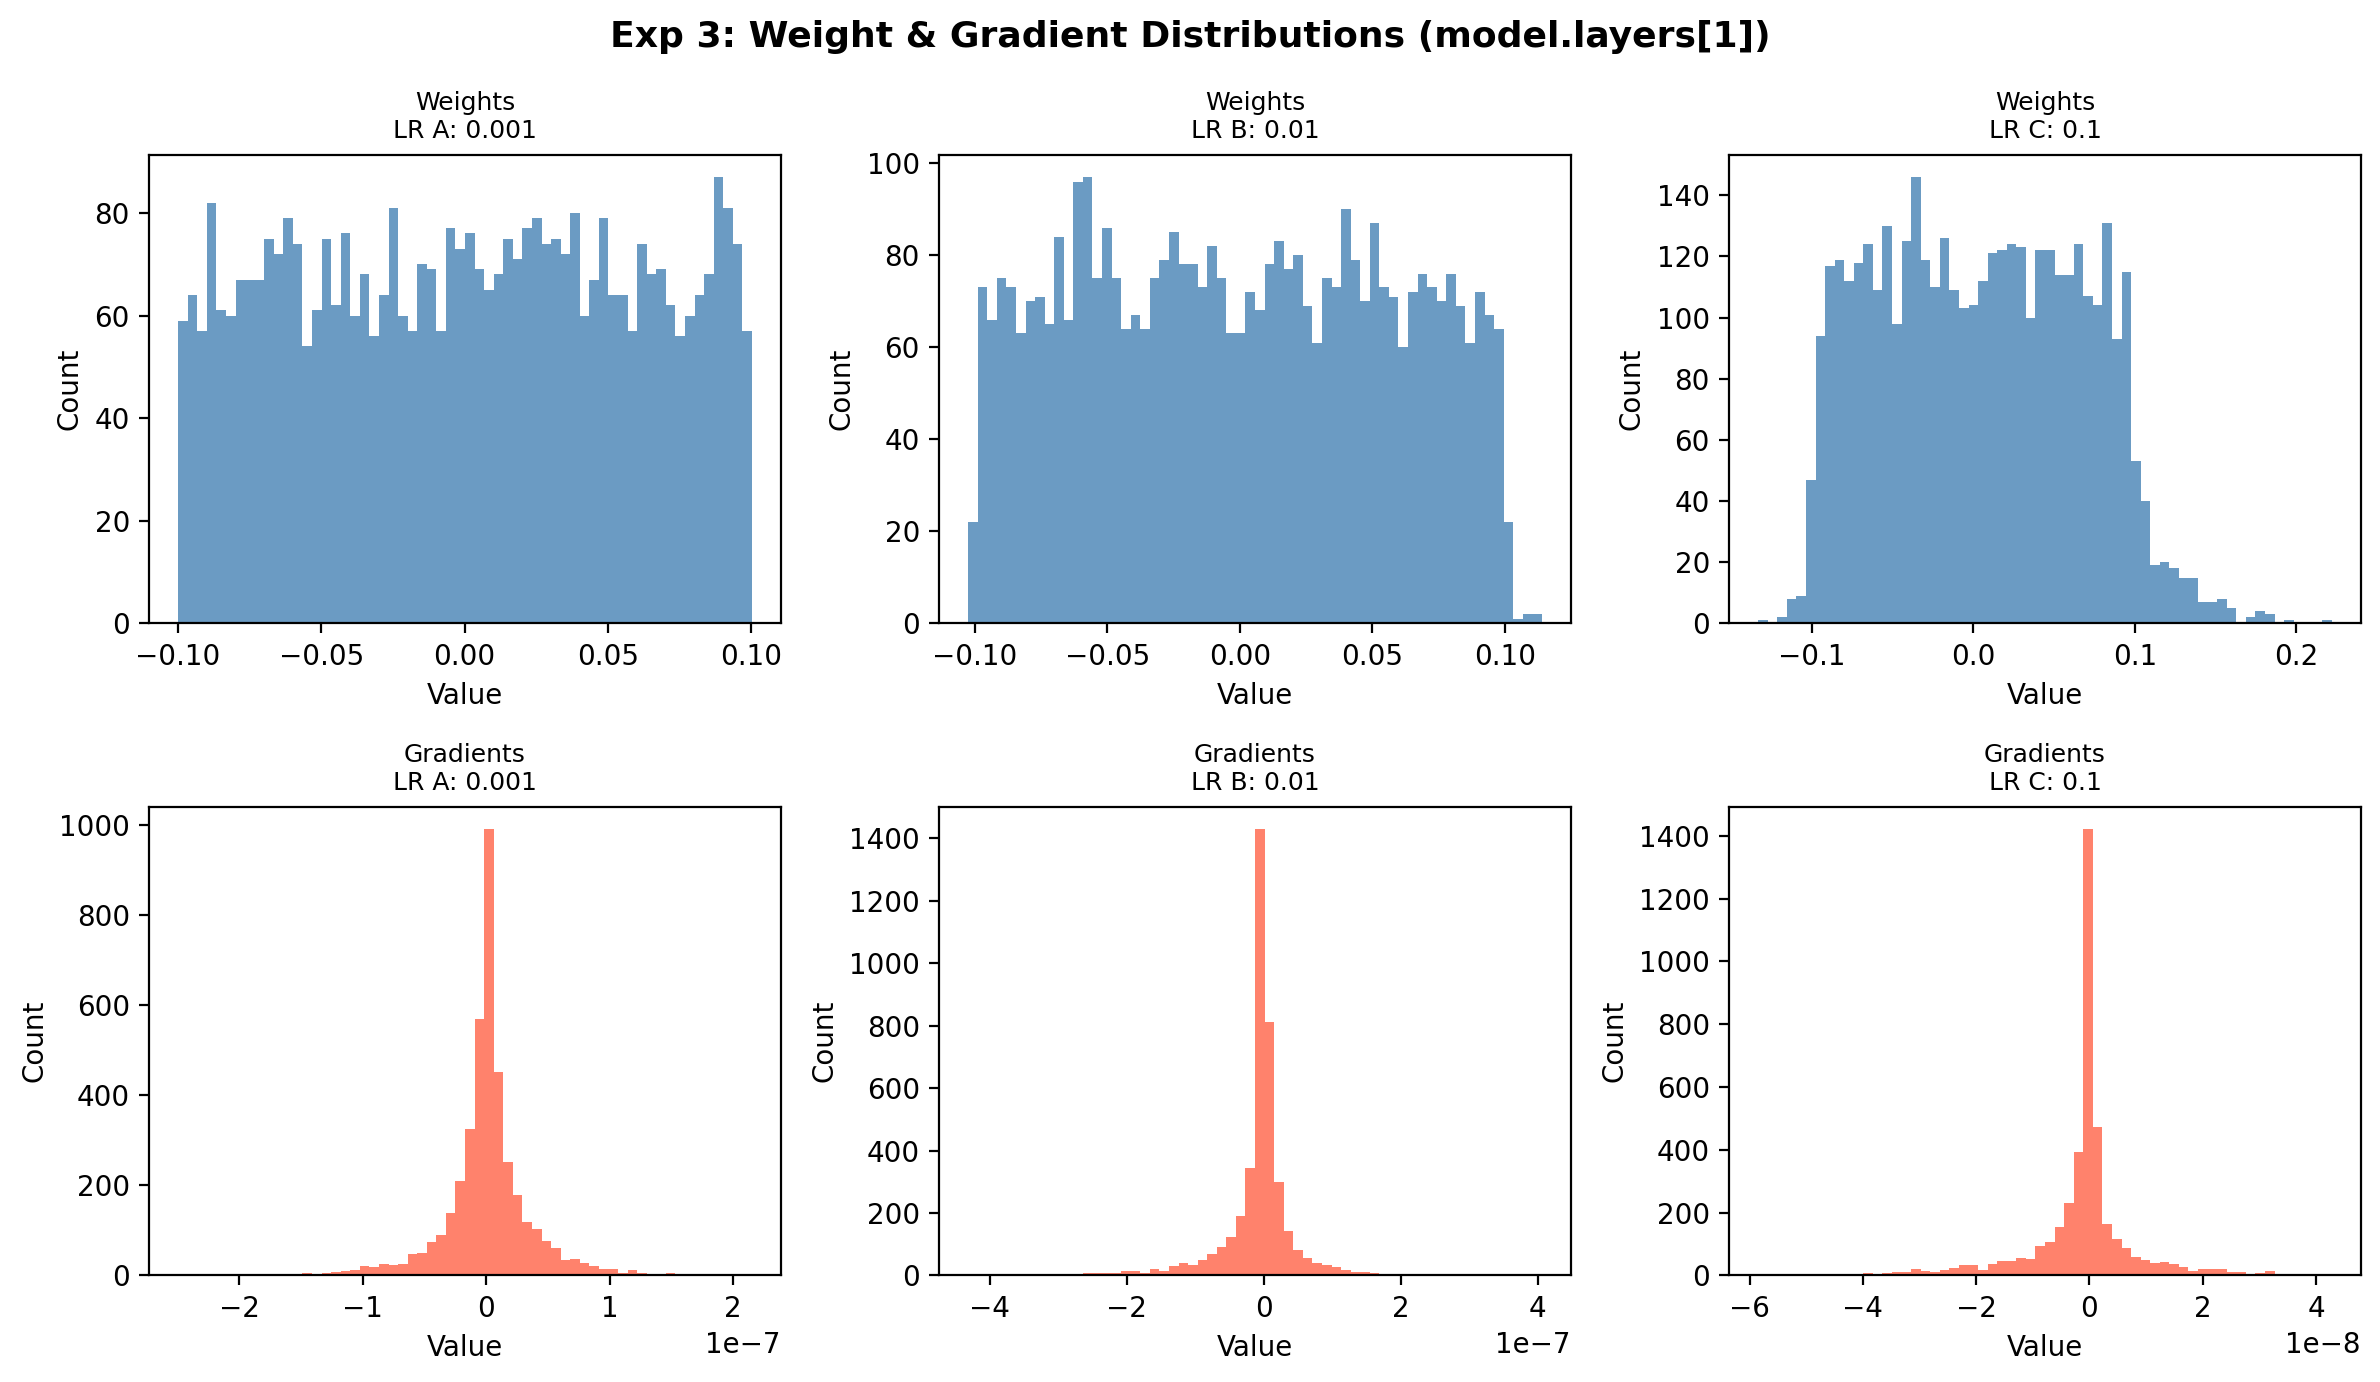


Exp 3 – Final Metrics
             Accuracy      F1  Precision  Recall
LR config                                       
LR A: 0.001    0.6106  0.4665     0.4312  0.6106
LR B: 0.01     0.7306  0.7340     0.7490  0.7306
LR C: 0.1      0.7512  0.7534     0.7588  0.7512


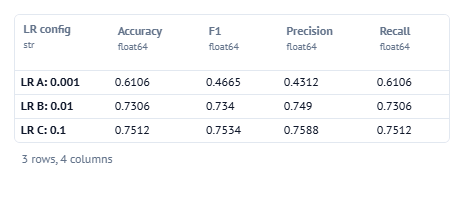

In [ ]:
_VIS_LAYER_IDX_3 = 1
_lrs = {"LR A: 0.001": 0.001, "LR B: 0.01": 0.01, "LR C: 0.1": 0.1}

_histories_3, _models_3, _labels_3, _rows_3 = [], [], [], []

for _lbl, _lr in _lrs.items():
    _model, _hist = build_and_train(
        [64, 64],
        ["relu", "relu"],
        lr=_lr,
        epochs=100,
        batch_size=32,
    )
    refresh_gradients(_model, X_train_final, y_train_final)
    _metrics = eval_model(_model, X_val_final, y_val_final)
    _histories_3.append(_hist)
    _models_3.append(_model)
    _labels_3.append(_lbl)
    _rows_3.append({"LR config": _lbl, **_metrics})

plot_loss_curves(
    _histories_3,
    _labels_3,
    "Exp 3: LR Variation – Train / Val Loss",
)
plot_wgrad_dists(
    _models_3,
    _labels_3,
    _VIS_LAYER_IDX_3,
    "Exp 3: Weight & Gradient Distributions (model.layers[1])",
)

_df_3 = pd.DataFrame(_rows_3).set_index("LR config")
print("\nExp 3 – Final Metrics")
print(_df_3.to_string())
_df_3

### Exp 4 – Regularization

Arsitektur: `input → 64 (relu) → 64 (relu) → output (sigmoid)`
Fixed: `lr=0.01`, `epochs=100`, `batch_size=32`

| Model | Regularizer |
|-------|-------------|
| A | None |
| B | L1, λ=0.001 |
| C | L2, λ=0.001 |

Expected observations:
- **Model A**: no penalty — possible overfitting (train loss well below val loss)
- **Model B (L1)**: sparse weights (many values near zero)
- **Model C (L2)**: small but non-zero weights (smoother distribution)

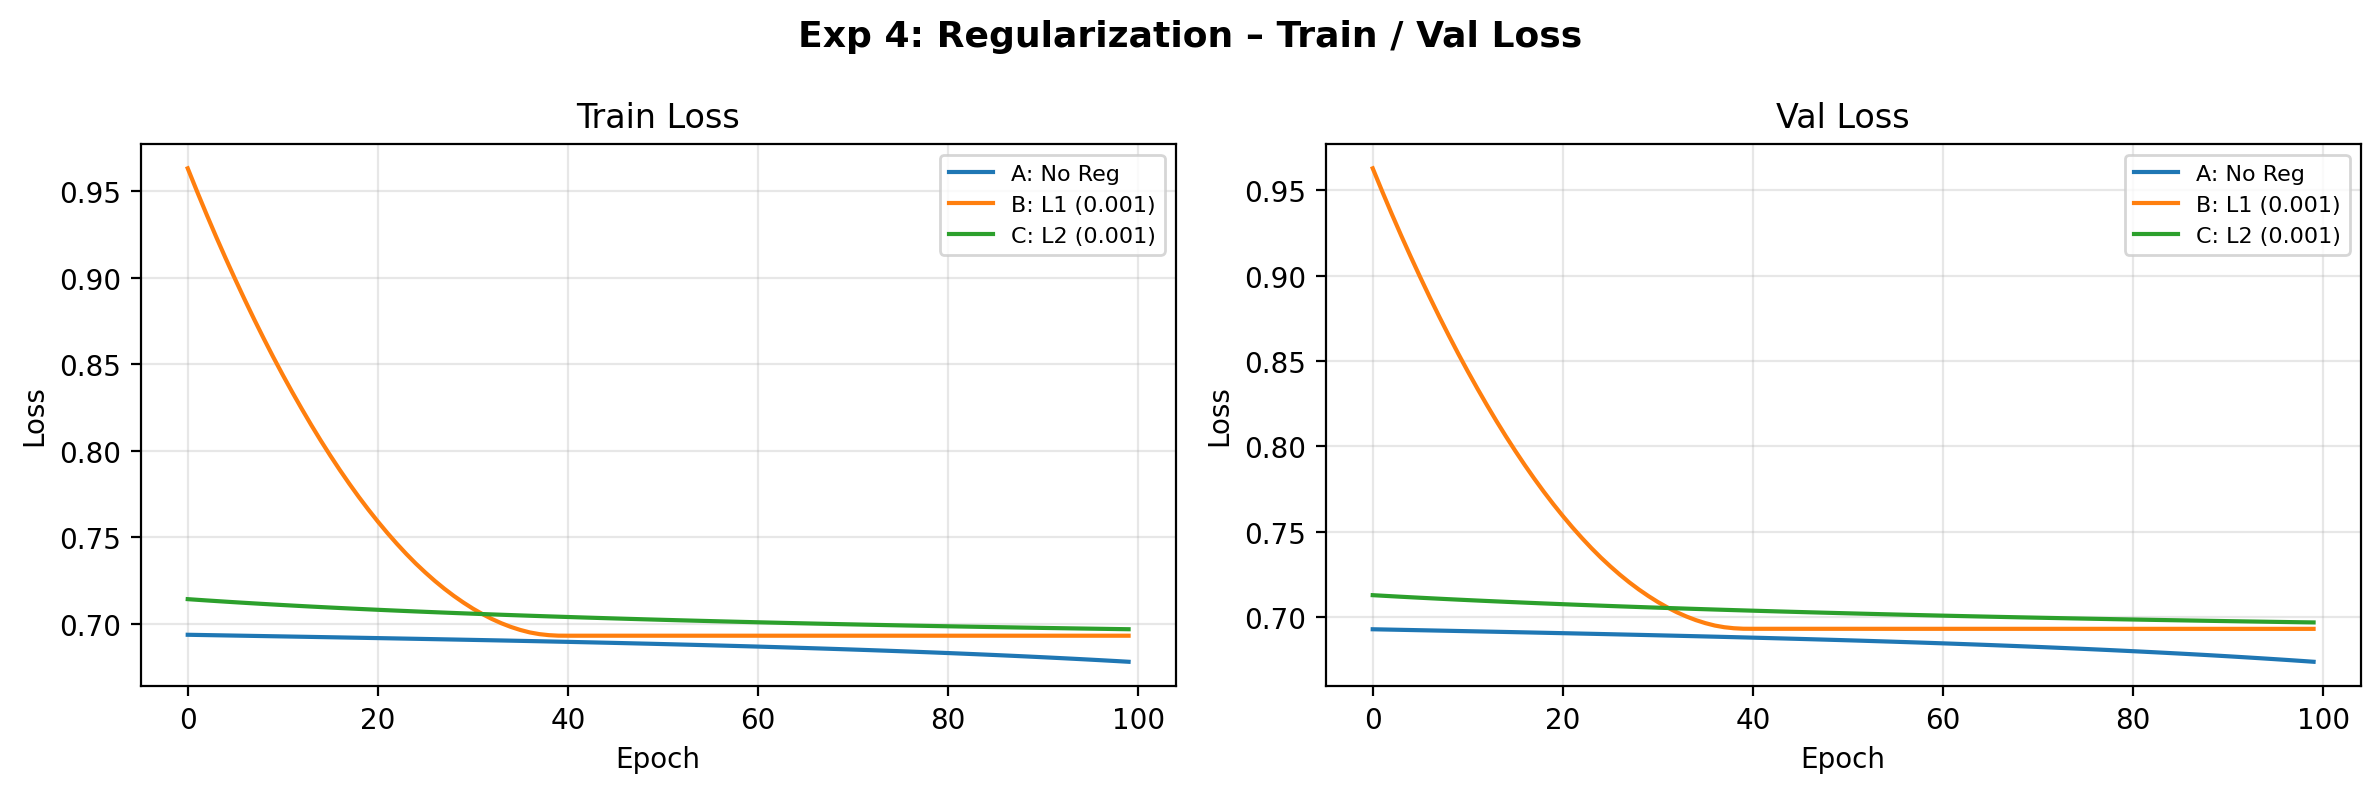

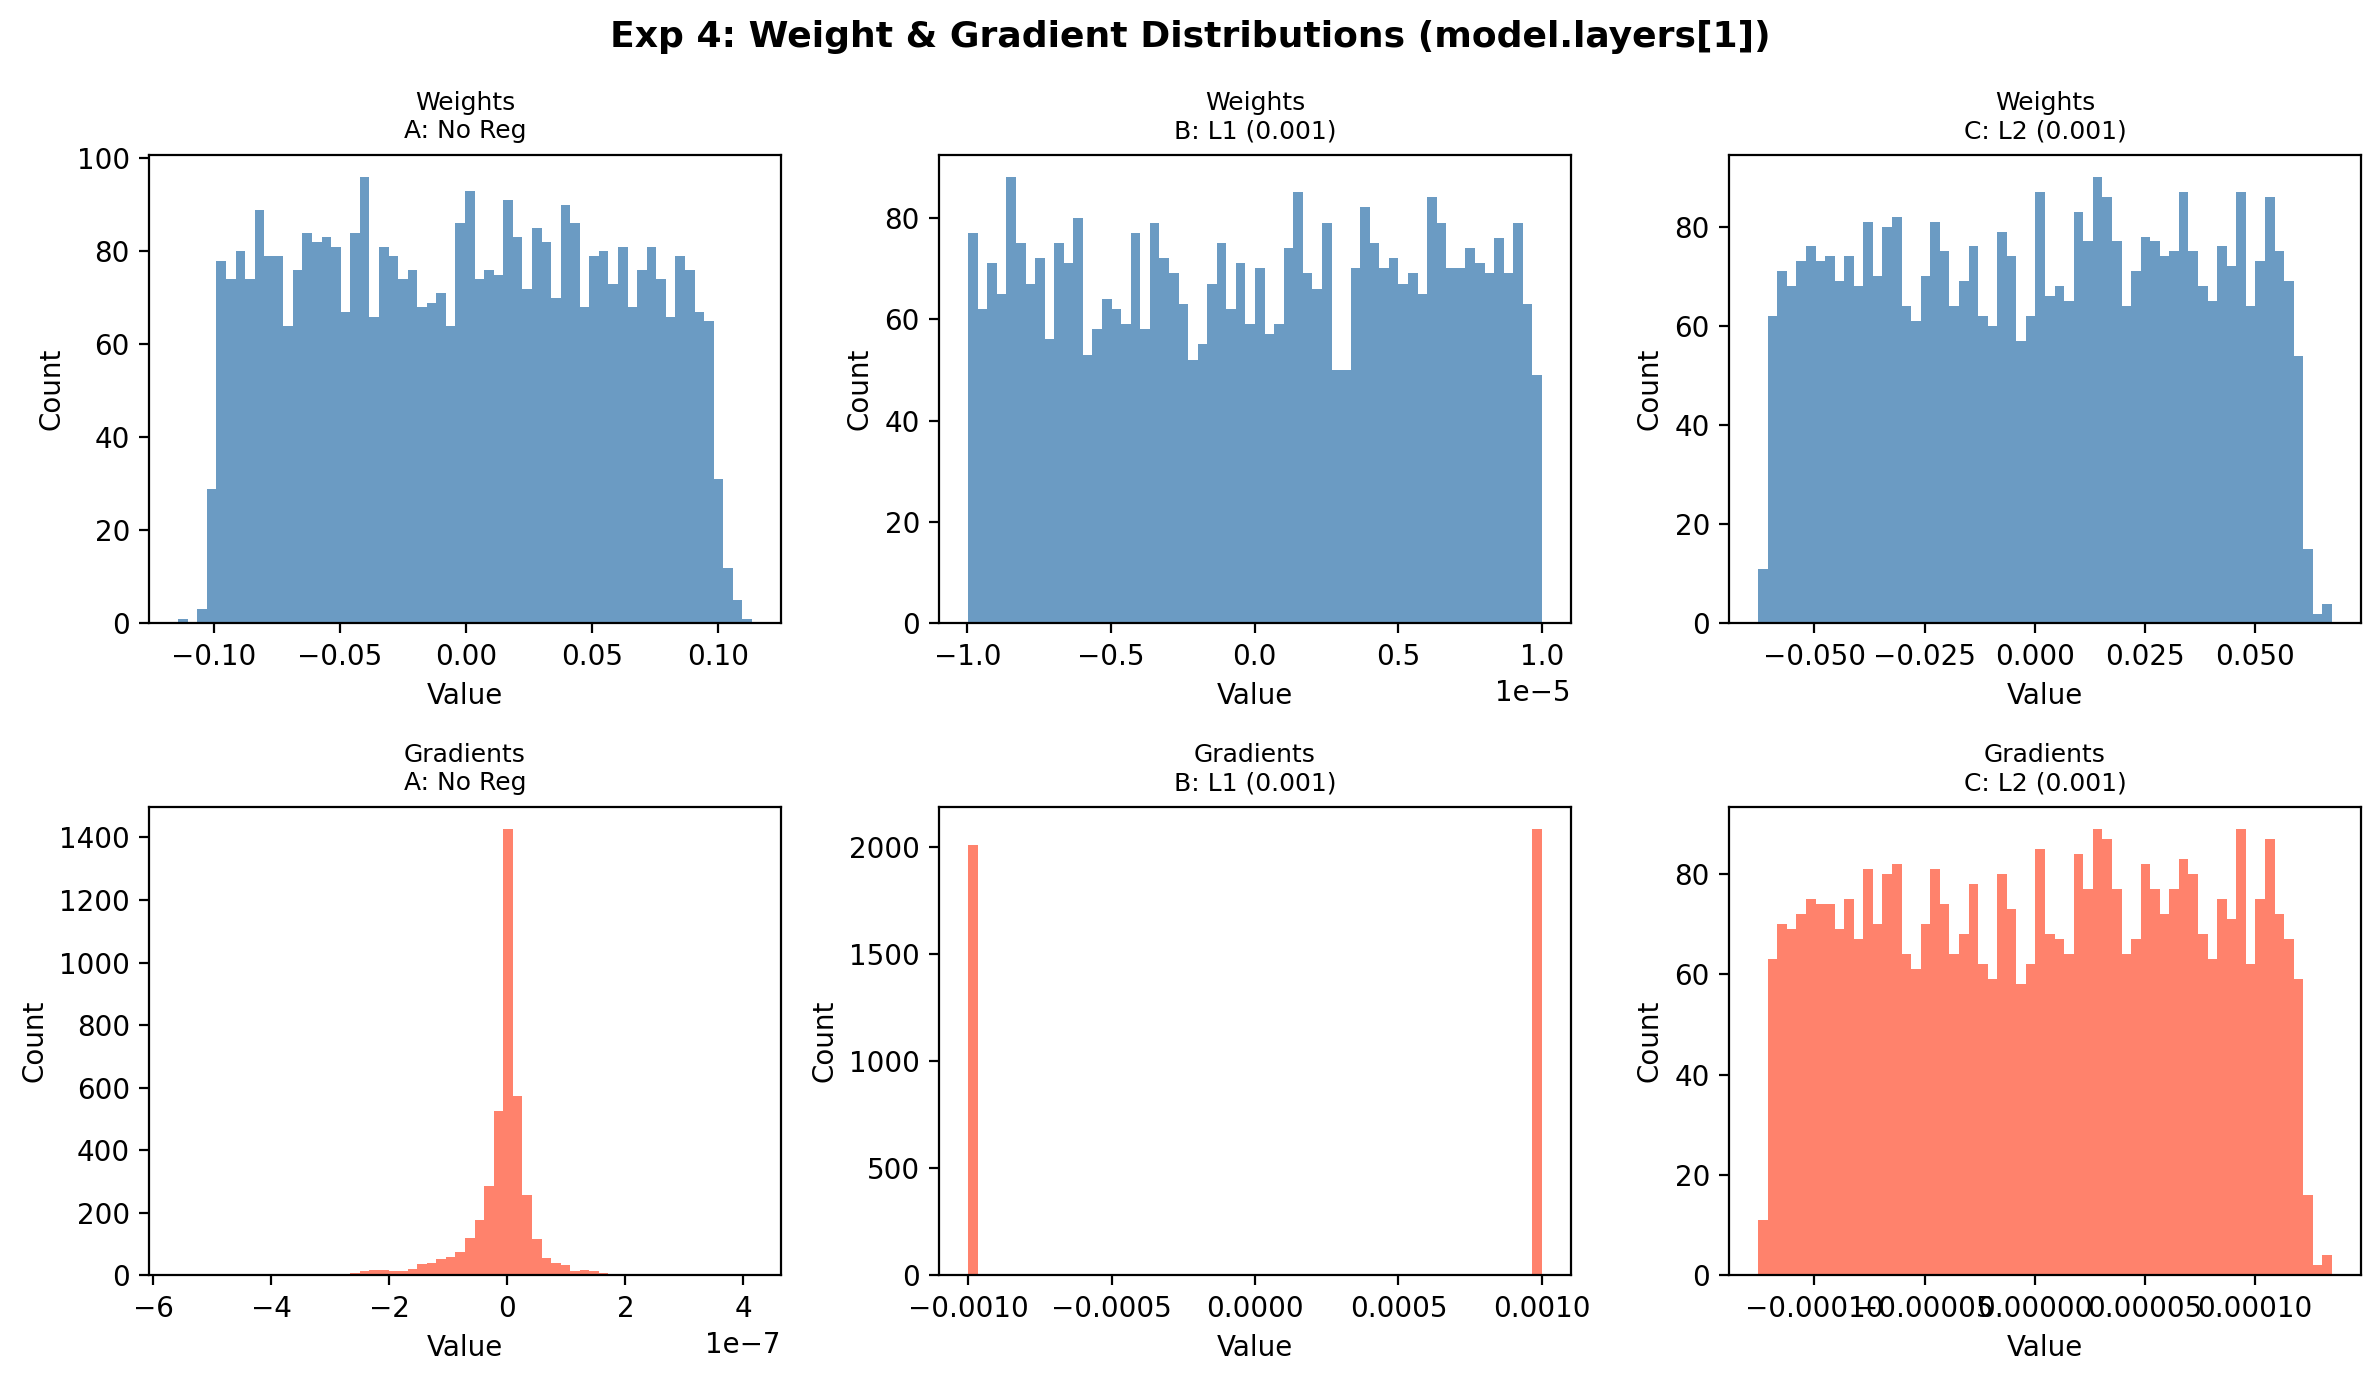


Exp 4 – Final Metrics
               Accuracy      F1  Precision  Recall
Regularizer                                       
A: No Reg        0.7512  0.7448     0.7480  0.7512
B: L1 (0.001)    0.3862  0.2152     0.1492  0.3862
C: L2 (0.001)    0.7181  0.7218     0.7414  0.7181


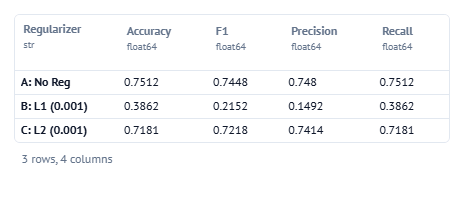

In [ ]:
_VIS_LAYER_IDX_4 = 1
_reg_configs = {
    "A: No Reg": dict(regularizer="none", reg_kwargs={}),
    "B: L1 (0.001)": dict(regularizer="l1", reg_kwargs={"lambda_": 0.001}),
    "C: L2 (0.001)": dict(regularizer="l2", reg_kwargs={"lambda_": 0.001}),
}

_histories_4, _models_4, _labels_4, _rows_4 = [], [], [], []

for _lbl, _cfg in _reg_configs.items():
    _model, _hist = build_and_train(
        [64, 64],
        ["relu", "relu"],
        lr=0.01,
        epochs=100,
        batch_size=32,
        regularizer=_cfg["regularizer"],
        reg_kwargs=_cfg["reg_kwargs"],
    )
    refresh_gradients(_model, X_train_final, y_train_final)
    _metrics = eval_model(_model, X_val_final, y_val_final)
    _histories_4.append(_hist)
    _models_4.append(_model)
    _labels_4.append(_lbl)
    _rows_4.append({"Regularizer": _lbl, **_metrics})

plot_loss_curves(
    _histories_4,
    _labels_4,
    "Exp 4: Regularization – Train / Val Loss",
)
plot_wgrad_dists(
    _models_4,
    _labels_4,
    _VIS_LAYER_IDX_4,
    "Exp 4: Weight & Gradient Distributions (model.layers[1])",
)

_df_4 = pd.DataFrame(_rows_4).set_index("Regularizer")
print("\nExp 4 – Final Metrics")
print(_df_4.to_string())
_df_4

### Exp 5 – Comparison with sklearn MLPClassifier

Fixed config: hidden=[64, 64], activation=relu, lr=0.01, epochs=100, batch_size=32.

**Fairness caveats**
- `solver='sgd'` is chosen so sklearn uses vanilla SGD, matching our update rule.
- `learning_rate='constant'` disables sklearn's default adaptive schedule.
- sklearn may differ in mini-batch shuffling, weight initialisation (Glorot uniform),
  and numerical precision of the loss gradient.
- Both models are evaluated on identical scaled test features.

C:\random-seed-42\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



Exp 5 – FFNN vs sklearn MLPClassifier
                   Accuracy      F1  Precision  Recall
Model                                                 
From scratch FFNN    0.7344  0.7343     0.7341  0.7344
sklearn MLP          0.6975  0.6977     0.6979  0.6975


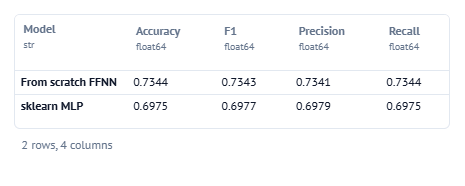

In [ ]:
from sklearn.neural_network import MLPClassifier

_scratch, _our_hist = build_and_train(
    [64, 64],
    ["relu", "relu"],
    lr=0.01,
    epochs=100,
    batch_size=32,
)
_scratch_metrics = eval_model(_scratch, X_val_final, y_val_final)

_sk = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="sgd",
    learning_rate="constant",
    learning_rate_init=0.01,
    max_iter=100,
    batch_size=32,
    random_state=42,
)
_sk.fit(X_train_final, y_train_final.ravel())
_sk_pred = _sk.predict(X_val_final)
_y_true = y_val_final.flatten().astype(int)
_kw = dict(average="weighted", zero_division=0)
_sk_metrics = {
    "Accuracy": round(accuracy_score(_y_true, _sk_pred), 4),
    "F1": round(f1_score(_y_true, _sk_pred, **_kw), 4),
    "Precision": round(precision_score(_y_true, _sk_pred, **_kw), 4),
    "Recall": round(recall_score(_y_true, _sk_pred, **_kw), 4),
}

_df_5 = pd.DataFrame(
    [
        {"Model": "From scratch FFNN", **_scratch_metrics},
        {"Model": "sklearn MLP", **_sk_metrics},
    ]
).set_index("Model")

print("\nExp 5 – FFNN vs sklearn MLPClassifier")
print(_df_5.to_string())
_df_5

### Exp 6 – Initializer Comparison

Architecture: `input → 64 (relu) → 64 (relu) → output (sigmoid)`
Fixed: `lr=0.01`, `epochs=100`, `batch_size=32`

| Config | Initializer |
|--------|-------------|
| A | Uniform |
| B | Xavier |
| C | He |

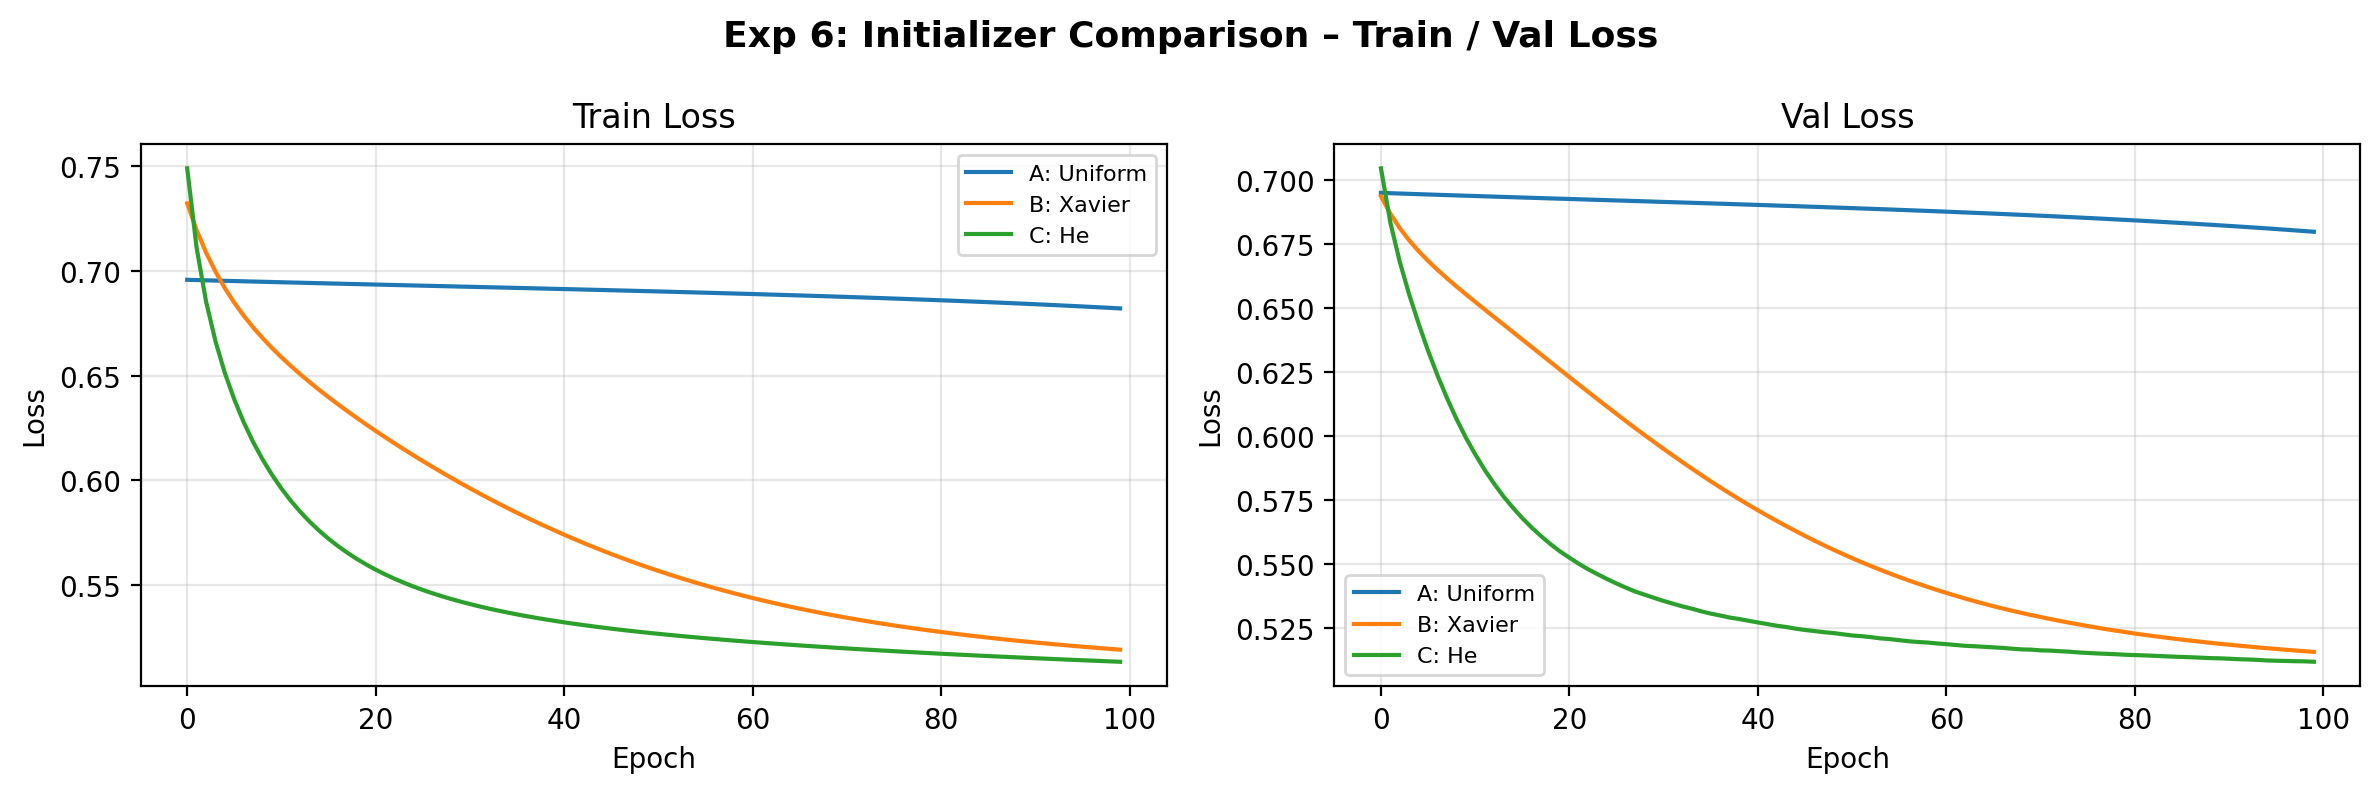


Exp 6 – Final Metrics
            Accuracy      F1  Precision  Recall
Config                                         
A: Uniform    0.7319  0.7311     0.7305  0.7319
B: Xavier     0.7500  0.7520     0.7568  0.7500
C: He         0.7356  0.7373     0.7403  0.7356


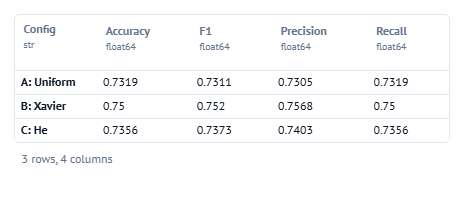

In [ ]:
_configs_6 = {
    "A: Uniform": "uniform",
    "B: Xavier": "xavier",
    "C: He": "he",
}

_histories_6, _rows_6 = [], []

for _lbl, _init in _configs_6.items():
    _model, _hist = build_and_train(
        [64, 64],
        ["relu", "relu"],
        lr=0.01,
        epochs=100,
        batch_size=32,
        initializer=_init,
    )
    _metrics = eval_model(_model, X_val_final, y_val_final)
    _histories_6.append(_hist)
    _rows_6.append({"Config": _lbl, **_metrics})

plot_loss_curves(
    _histories_6,
    list(_configs_6.keys()),
    "Exp 6: Initializer Comparison – Train / Val Loss",
)

_df_6 = pd.DataFrame(_rows_6).set_index("Config")
print("\nExp 6 – Final Metrics")
print(_df_6.to_string())
_df_6